<a href="https://colab.research.google.com/github/masterAristocats/Proc-Sin-Trabalho-Extra/blob/main/examples/beampattern.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


###Exemplo de utilização

## Objetivo

Implementar a função `beampattern(positions, azimuth, elevation, wavelength)` responsável por calcular o ganho espacial de um arranjo de sensores.


In [3]:
!git clone https://github.com/masterAristocats/Proc-Sin-Trabalho-Extra.git

fatal: destination path 'Proc-Sin-Trabalho-Extra' already exists and is not an empty directory.


In [4]:
%cd Proc-Sin-Trabalho-Extra

!ls src

/content/Proc-Sin-Trabalho-Extra
beamformer.py	generate_uca.py   generate_ula.py  steering_vector.py
beampattern.py	generate_ucya.py  generate_upa.py


In [5]:
import numpy as np
import matplotlib.pyplot as plt

from src.generate_ula import generate_ula
from src.generate_uca import generate_uca
from src.generate_upa import generate_upa
from src.generate_ucya import generate_ucya
from src.steering_vector import steering_vector

from src.beampattern import beampattern

##Definir parâmetros

In [6]:
M = 9

wavelength = 1

d = wavelength / 2

positions = generate_ula(M, d)

## Cálculo do Beampattern

Neste exemplo considera-se um Arranjo Linear Uniforme (ULA) com nove sensores e espaçamento igual a metade do comprimento de onda.

O ganho é calculado para ângulos de elevação entre -90° e 90°.

In [7]:
theta = np.linspace(-90,90,721)

theta_rad = np.deg2rad(theta)

gain = beampattern(
    positions,
    azimuth=0,
    elevation=theta_rad,
    wavelength=wavelength
)

## Beampattern

O gráfico abaixo apresenta o ganho espacial normalizado em função do ângulo de observação.

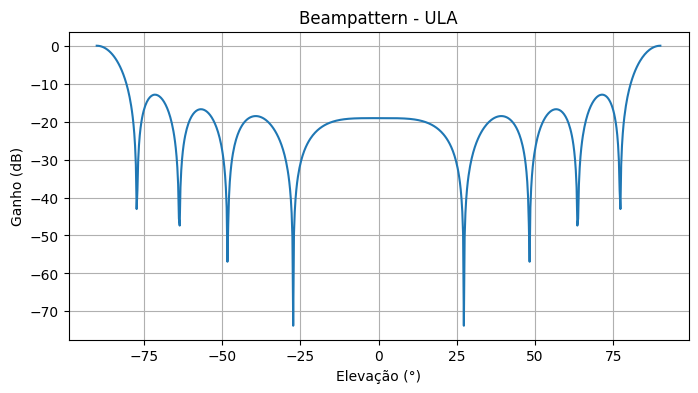

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(theta,gain)

plt.xlabel("Elevação (°)")
plt.ylabel("Ganho (dB)")

plt.title("Beampattern - ULA")

plt.grid(True)

plt.show()

## Interpretação

O pico do gráfico corresponde ao **lóbulo principal**, indicando a direção de maior ganho do arranjo.

Os demais máximos locais representam os **lóbulos secundários**, responsáveis pela recepção de sinais provenientes de outras direções.

A largura do lóbulo principal está relacionada diretamente à capacidade de resolução angular do arranjo.

In [9]:
weights = np.ones(M,dtype=complex)

AF = []

for ang in theta_rad:

    a = steering_vector(
        positions,
        0,
        ang,
        wavelength
    )

    AF.append(np.conjugate(weights) @ a)

AF = np.array(AF)

## Array Factor no Plano Complexo

Antes da normalização, o beampattern é obtido a partir do módulo do Array Factor.

O gráfico abaixo apresenta a parte real e a parte imaginária do Array Factor em função do ângulo de observação.

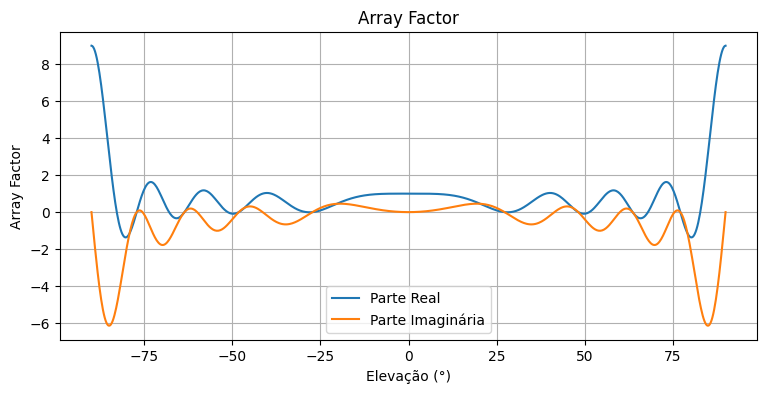

In [10]:
plt.figure(figsize=(9,4))

plt.plot(theta,np.real(AF),label="Parte Real")

plt.plot(theta,np.imag(AF),label="Parte Imaginária")

plt.xlabel("Elevação (°)")

plt.ylabel("Array Factor")

plt.title("Array Factor")

plt.grid(True)

plt.legend()

plt.show()

# Beampattern

## Modelagem Matemática

Considere o vetor diretor

\[
\mathbf a(\theta,\phi).
\]

e o vetor de pesos complexo

\[
\mathbf w.
\]

O fator de arranjo (Array Factor) é definido por

\[
AF(\theta,\phi)=\mathbf w^H\mathbf a(\theta,\phi),
\]

onde \((\cdot)^H\) representa o conjugado transposto.

O ganho normalizado é obtido por

\[
B(\theta,\phi)=
\frac{|AF(\theta,\phi)|}
{\max |AF(\theta,\phi)|}.
\]

Finalmente, o ganho é convertido para decibéis através de

\[
B_{dB}=20\log_{10}(B).
\]

Neste trabalho são utilizados inicialmente pesos uniformes

\[
\mathbf w=
\begin{bmatrix}
1&1&\cdots&1
\end{bmatrix}^T.
\]

O beampattern permite visualizar a diretividade do arranjo e identificar o lóbulo principal, os lóbulos secundários e a largura de feixe.